In [1]:
import os
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

In [2]:
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text

print("length:", len(text))

from collections import defaultdict, Counter

def get_vocab(text):
    vocab = Counter()
    for word in text.split():
        chars = tuple(word) + ("</w>",)
        vocab[chars] += 1
    return vocab

length: 1115394


In [3]:
import re
import math
from collections import Counter, defaultdict

# =========================
# 1. 更好的 tokenizer
# =========================
def pretokenize(text):
    # 分离单词 + 标点
    return re.findall(r"\w+|[^\w\s]", text.lower())


# =========================
# 2. vocab 构建
# =========================
def get_vocab(text_tokens):
    vocab = Counter()
    for token in text_tokens:
        chars = tuple(token) + ("</w>",)
        vocab[chars] += 1
    return vocab


def get_base_vocab(text_tokens):
    base_vocab = set()
    for token in text_tokens:
        for ch in token:
            base_vocab.add(ch)
    base_vocab.update(["</w>", "<unk>"])
    return base_vocab


# =========================
# 3. BPE stats
# =========================
def get_stats(vocab):
    pairs = Counter()
    for word, freq in vocab.items():
        for i in range(len(word) - 1):
            pairs[(word[i], word[i+1])] += freq
    return pairs


# =========================
# 4. merge（正确版本）
# =========================
def merge_vocab(pair, vocab):
    new_vocab = {}

    for word, freq in vocab.items():
        new_word = []
        i = 0

        while i < len(word):
            if i < len(word) - 1 and (word[i], word[i+1]) == pair:
                new_word.append(word[i] + word[i+1])
                i += 2
            else:
                new_word.append(word[i])
                i += 1

        new_vocab[tuple(new_word)] = freq

    return new_vocab


# =========================
# 5. BPE training
# =========================
def train_bpe(text_tokens, max_vocab_size=500):

    vocab = get_vocab(text_tokens)
    base_vocab = get_base_vocab(text_tokens)

    merges = []
    target_merges = max_vocab_size - len(base_vocab)

    print("base vocab:", len(base_vocab))
    print("target merges:", target_merges)

    for _ in range(target_merges):
        pairs = get_stats(vocab)
        if not pairs:
            break

        best = max(pairs, key=pairs.get)

        # prune low-frequency merges
        if pairs[best] < 2:
            break

        vocab = merge_vocab(best, vocab)
        merges.append(best)

    return merges, base_vocab


# =========================
# 6. encode word
# =========================
def encode_word(word, merges):
    tokens = list(word) + ["</w>"]

    for pair in merges:
        i = 0
        new_tokens = []

        while i < len(tokens):
            if i < len(tokens)-1 and (tokens[i], tokens[i+1]) == pair:
                new_tokens.append(tokens[i] + tokens[i+1])
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1

        tokens = new_tokens

    return tokens


# =========================
# 7. encode full text
# =========================
def encode(text_tokens, merges):
    tokens = []
    for word in text_tokens:
        tokens.extend(encode_word(word, merges))
    return tokens


# =========================
# 8. build vocab
# =========================
def build_vocab(base_vocab, merges):
    vocab = set(base_vocab)
    for pair in merges:
        vocab.add("".join(pair))
    return sorted(vocab)


# =========================
# 9. full pipeline
# =========================
text_tokens = pretokenize(text)

merges, base_vocab = train_bpe(text_tokens, max_vocab_size=500)

full_vocab = build_vocab(base_vocab, merges)

stoi = {tok: i for i, tok in enumerate(full_vocab)}
itos = {i: tok for tok, i in stoi.items()}

# =========================
# 10. encode dataset
# =========================
tokens = encode(text_tokens, merges)

ids = [stoi.get(t, stoi["<unk>"]) for t in tokens]

print("vocab size:", len(full_vocab))
print("max id:", max(ids))
assert max(ids) < len(full_vocab)

base vocab: 39
target merges: 461


vocab size: 500
max id: 499


In [4]:
def create_sequences(token_ids, seq_len=50, stride=25):
    inputs = []
    targets = []

    for i in range(0, len(token_ids) - seq_len, stride):
        x = token_ids[i:i+seq_len]
        y = token_ids[i+1:i+seq_len+1]

        inputs.append(x)
        targets.append(y)

    return inputs, targets

In [ ]:

import torch
from torch.utils.data import Dataset

class ShakespeareDataset(Dataset):
    def __init__(self, token_ids, seq_len=50):
        self.inputs, self.targets = create_sequences(token_ids, seq_len)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.inputs[idx], dtype=torch.long),
            torch.tensor(self.targets[idx], dtype=torch.long),
        )


from torch.utils.data import DataLoader


In [ ]:
import numpy as np

seq_len = 10
batch_size = 16

ids = np.array(ids)

split_idx = int(len(ids) * 0.8)

train_ids = ids[:split_idx]
val_ids = ids[split_idx:]

print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))


train_dataset = ShakespeareDataset(train_ids, seq_len)
val_dataset = ShakespeareDataset(val_ids, seq_len)

from torch.utils.data import DataLoader

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    generator=g
)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print("train samples:", len(train_dataset))
print("val samples:", len(val_dataset))

import torch.nn as nn

vocab_size = len(full_vocab)
d_model = 128  

token_embedding = nn.Embedding(vocab_size, d_model)

train tokens: 347377
val tokens: 86845
train samples: 13894
val samples: 3472


In [8]:
import torch
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0) 

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len].to(x.device)

class InputEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model)

    def forward(self, x):
        x = self.token_emb(x)         
        x = self.pos_enc(x)            
        return x

device = "cuda" if torch.cuda.is_available() else "cpu"

model_input = InputEmbedding(vocab_size, d_model).to(device)

for x, y in train_loader:
    x = x.to(device)
    out = model_input(x)

    print("input shape:", x.shape)      
    print("embedding shape:", out.shape)  
    break

input shape: torch.Size([16, 50])
embedding shape: torch.Size([16, 50, 128])


In [9]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import math

# class RMSNorm(nn.Module):
#     def __init__(self, dim, eps=1e-8):
#         super().__init__()
#         self.scale = nn.Parameter(torch.ones(dim))
#         self.eps = eps

#     def forward(self, x):
#         norm = x.pow(2).mean(-1, keepdim=True) + self.eps
#         norm = norm.sqrt()
#         return self.scale * x / norm

# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model, max_len=5000):
#         super().__init__()

#         pe = torch.zeros(max_len, d_model)
#         pos = torch.arange(0, max_len).unsqueeze(1)

#         div = torch.exp(
#             torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
#         )

#         pe[:, 0::2] = torch.sin(pos * div)
#         pe[:, 1::2] = torch.cos(pos * div)

#         self.register_buffer("pe", pe.unsqueeze(0))

#     def forward(self, x):
#         return x + self.pe[:, :x.size(1)]

# class SelfAttention(nn.Module):
#     def __init__(self, d_model, num_heads):
#         super().__init__()
#         assert d_model % num_heads == 0

#         self.d_model = d_model
#         self.num_heads = num_heads
#         self.head_dim = d_model // num_heads

#         self.qkv = nn.Linear(d_model, 3 * d_model)
#         self.proj = nn.Linear(d_model, d_model)

#     def forward(self, x, return_attn=False):
#         B, T, C = x.shape

#         qkv = self.qkv(x)
#         q, k, v = qkv.chunk(3, dim=-1)

#         q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
#         k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
#         v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

#         attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

#         mask = torch.tril(torch.ones(T, T, device=x.device))
#         attn = attn.masked_fill(mask == 0, float("-inf"))

#         attn = F.softmax(attn, dim=-1)

#         out = attn @ v
#         out = out.transpose(1, 2).contiguous().view(B, T, C)
#         out = self.proj(out)

#         if return_attn:
#             return out, attn.detach()
#         return out

# class FeedForward(nn.Module):
#     def __init__(self, d_model):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(d_model, 4 * d_model),
#             nn.GELU(),
#             nn.Dropout(0.1),
#             nn.Linear(4 * d_model, d_model),
#         )

#     def forward(self, x):
#         return self.net(x)

# class TransformerBlock(nn.Module):
#     def __init__(self, d_model, num_heads):
#         super().__init__()
#         self.norm1 = RMSNorm(d_model)
#         self.attn = SelfAttention(d_model, num_heads)
#         self.norm2 = RMSNorm(d_model)
#         self.ffn = FeedForward(d_model)

#     def forward(self, x, return_attn=False):
#         if return_attn:
#             attn_out, attn = self.attn(self.norm1(x), return_attn=True)
#             x = x + attn_out
#             x = x + self.ffn(self.norm2(x))
#             return x, attn
#         else:
#             x = x + self.attn(self.norm1(x))
#             x = x + self.ffn(self.norm2(x))
#             return x        

# class TinyTransformer(nn.Module):
#     def __init__(self, vocab_size, d_model=128, num_layers=2, num_heads=4):
#         super().__init__()

#         self.token_emb = nn.Embedding(vocab_size, d_model)
#         self.pos_enc = PositionalEncoding(d_model)

#         self.blocks = nn.ModuleList([
#             TransformerBlock(d_model, num_heads)
#             for _ in range(num_layers)
#         ])

#         self.norm = RMSNorm(d_model)
#         self.lm_head = nn.Linear(d_model, vocab_size)

#     def forward(self, x, return_attn=False):
#         x = self.token_emb(x)
#         x = self.pos_enc(x)

#         attn_maps = []

#         for block in self.blocks:
#             if return_attn:
#                 x, attn = block(x, return_attn=True)
#                 attn_maps.append(attn)
#             else:
#                 x = block(x)

#         x = self.norm(x)
#         logits = self.lm_head(x)

#         if return_attn:
#             return logits, attn_maps
#         return logits


import torch
import torch.nn as nn
import torch.nn.functional as F
import math


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)

        div = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class SelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0

        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x, return_attn=False):
        B, T, C = x.shape

        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        mask = torch.tril(torch.ones(T, T, device=x.device))
        attn = attn.masked_fill(mask == 0, float("-inf"))

        attn = F.softmax(attn, dim=-1)

        out = attn @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.proj(out)

        if return_attn:
            return out, attn.detach()
        return out


class FeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(4 * d_model, d_model),
        )

    def forward(self, x):
        return self.net(x)

class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        self.norm1 = nn.LayerNorm(d_model)
        self.attn = SelfAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model)

    def forward(self, x, return_attn=False):

        if return_attn:
            attn_out, attn = self.attn(self.norm1(x), return_attn=True)
            x = x + attn_out
            x = x + self.ffn(self.norm2(x))
            return x, attn
        else:
            x = x + self.attn(self.norm1(x))
            x = x + self.ffn(self.norm2(x))
            return x


class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_layers=2, num_heads=4):
        super().__init__()

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads)
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(d_model)

        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, return_attn=False):

        x = self.token_emb(x)
        x = self.pos_enc(x)

        attn_maps = []

        for block in self.blocks:
            if return_attn:
                x, attn = block(x, return_attn=True)
                attn_maps.append(attn)
            else:
                x = block(x)

        x = self.norm(x)
        logits = self.lm_head(x)

        if return_attn:
            return logits, attn_maps
        return logits

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"

lr=1e-3
decay=0.01
model = TinyTransformer(vocab_size).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr,
    # betas=(0.9, 0.95),
    weight_decay=decay
)
loss_fn = nn.CrossEntropyLoss()

def train_epoch(loader):
    model.train()
    total_loss = 0
    total_tokens = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)

        loss = F.cross_entropy(
            logits.view(-1, vocab_size),
            y.view(-1),
            reduction='sum'   
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_tokens += y.numel()

    return total_loss / total_tokens

@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0
    total_tokens = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)

        loss = F.cross_entropy(
            logits.view(-1, vocab_size),
            y.view(-1),
            reduction='sum'
        )

        total_loss += loss.item()
        total_tokens += y.numel()

    return total_loss / total_tokens

In [ ]:
import copy

epochs = 10

train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model_state = None

for epoch in range(epochs):
    train_loss = train_epoch(train_loader)
    val_loss = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} | train: {train_loss:.4f} | val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

Epoch 1 | train: 4.2324 | val: 4.1865
Epoch 2 | train: 3.5951 | val: 3.9993
Epoch 3 | train: 3.3819 | val: 3.9498
Epoch 4 | train: 3.2543 | val: 3.9373
Epoch 5 | train: 3.1612 | val: 3.9316
Epoch 6 | train: 3.0866 | val: 3.9542
Epoch 7 | train: 3.0246 | val: 3.9785
Epoch 8 | train: 2.9705 | val: 4.0118
Epoch 9 | train: 2.9227 | val: 4.0311
Epoch 10 | train: 2.8799 | val: 4.0883
Epoch 11 | train: 2.8425 | val: 4.0900
Epoch 12 | train: 2.8058 | val: 4.1044
Epoch 13 | train: 2.7753 | val: 4.1462
Epoch 14 | train: 2.7454 | val: 4.1810
Epoch 15 | train: 2.7190 | val: 4.2035
Epoch 16 | train: 2.6939 | val: 4.2360
Epoch 17 | train: 2.6715 | val: 4.2634
Epoch 18 | train: 2.6499 | val: 4.2767
Epoch 19 | train: 2.6301 | val: 4.3185
Epoch 20 | train: 2.6107 | val: 4.3280


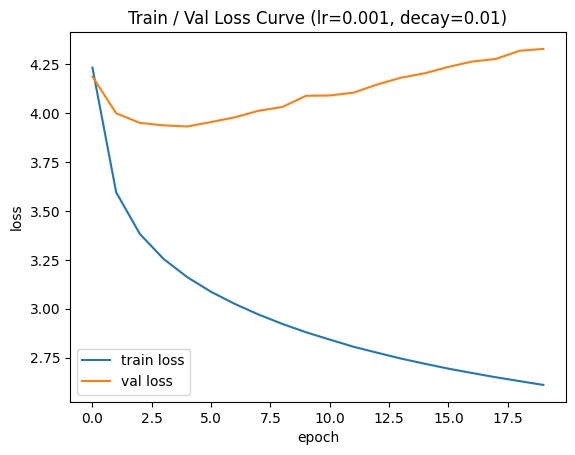

In [26]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Train / Val Loss Curve (lr={lr}, decay={decay})")
plt.legend()
plt.show()

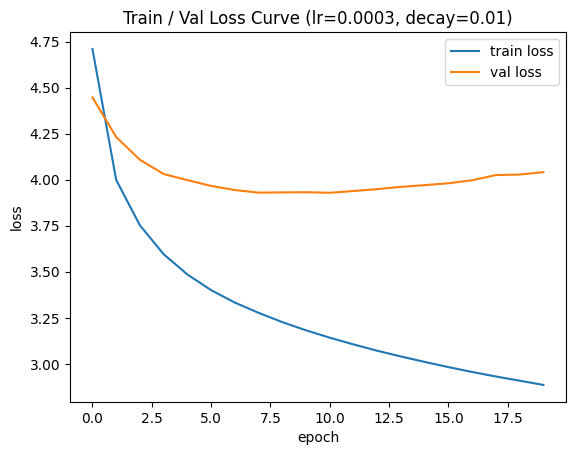

In [12]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Train / Val Loss Curve (lr={lr}, decay={decay})")
plt.legend()
plt.show()

In [19]:
for i in range(10,15):
    x, y = val_dataset[i]

    tokens = [itos[idx.item()] for idx in x]
    target_tokens = [itos[idx.item()] for idx in y]

    print(f"\n--- sample {i} ---")
    print("input tokens : ", tokens)
    print("target tokens: ", target_tokens)


--- sample 10 ---
input tokens :  ['ne', 'y</w>', ',</w>', 'and</w>', 'death</w>', 'un', 'lo', 'a', 'ds</w>', 'thee</w>', '.</w>', 'fri', 'end</w>', 'ha', 'st</w>', 'thou</w>', 'no', 'ne</w>', ';</w>', 'for</w>', 'th', 'ine</w>', 'o', 'wn</w>', 'bo', 'w', 'el', 's</w>', ',</w>', 'which</w>', 'do</w>', 'ca', 'll</w>', 'thee</w>', 'si', 'r', 'e</w>', ',</w>', 'the</w>', 'm', 'ere</w>', 'e', 'f', 'fu', 'si', 'on</w>', 'of</w>', 'thy</w>', 'pro', 'p']
target tokens:  ['y</w>', ',</w>', 'and</w>', 'death</w>', 'un', 'lo', 'a', 'ds</w>', 'thee</w>', '.</w>', 'fri', 'end</w>', 'ha', 'st</w>', 'thou</w>', 'no', 'ne</w>', ';</w>', 'for</w>', 'th', 'ine</w>', 'o', 'wn</w>', 'bo', 'w', 'el', 's</w>', ',</w>', 'which</w>', 'do</w>', 'ca', 'll</w>', 'thee</w>', 'si', 'r', 'e</w>', ',</w>', 'the</w>', 'm', 'ere</w>', 'e', 'f', 'fu', 'si', 'on</w>', 'of</w>', 'thy</w>', 'pro', 'p', 'er</w>']

--- sample 11 ---
input tokens :  ['w', 'el', 's</w>', ',</w>', 'which</w>', 'do</w>', 'ca', 'll</w>', 'thee

In [28]:
model.load_state_dict(best_model_state)
print("Loaded best model with val loss:", best_val_loss)

Loaded best model with val loss: 3.931585488033734


num layers: 2


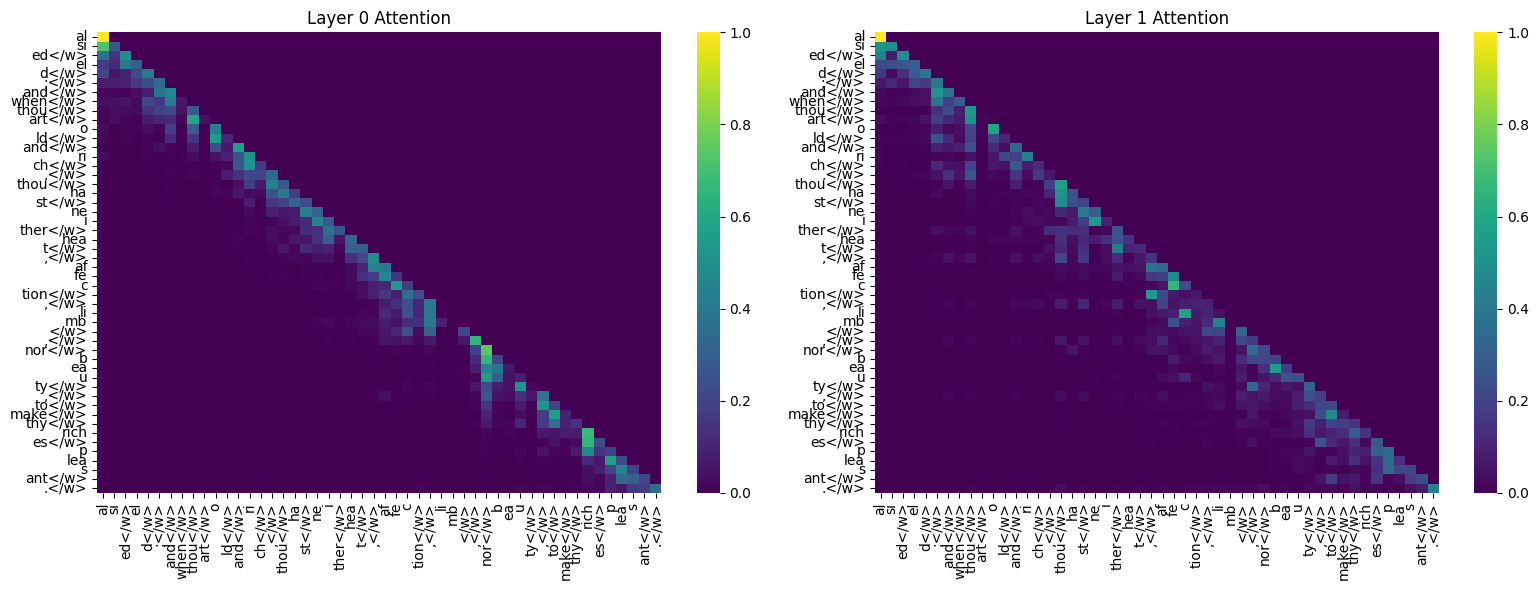

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def plot_attention_two_layers(model, dataset, stoi, itos, device):
    model.eval()

    x, y = dataset[14]
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        logits, attn_maps = model(x, return_attn=True)

    print("num layers:", len(attn_maps))

    tokens = [itos[i.item()] for i in x[0]]

    # 取前两个 layer
    layer0 = attn_maps[0][0].mean(0).detach().cpu().numpy()
    layer1 = attn_maps[1][0].mean(0).detach().cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(
        layer0,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="viridis",
        ax=axes[0]
    )
    axes[0].set_title("Layer 0 Attention")

    sns.heatmap(
        layer1,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="viridis",
        ax=axes[1]
    )
    axes[1].set_title("Layer 1 Attention")

    plt.tight_layout()
    plt.show()

print(f'lr: {lr}, decay: {decay}')
plot_attention_two_layers(model, val_dataset, stoi, itos, device)

In [29]:
import math
loss_fn = nn.CrossEntropyLoss(reduction='sum')
@torch.no_grad()
def compute_ppl(loader):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        # print('x:',x[0][:10])
        # print('y:',y[0][:10])

        logits = model(x)

        loss = loss_fn(
            logits.view(-1, vocab_size),
            y.view(-1)
        )

        total_loss += loss.item()
        total_tokens += y.numel()

    avg_loss = total_loss / total_tokens
    print("avg_loss:", avg_loss)
    ppl = math.exp(avg_loss)

    return ppl

In [30]:
val_ppl = compute_ppl(val_loader)
print(f"lr={lr}, decay={decay}, Validation Perplexity: {val_ppl}")



avg_loss: 3.931585488033734
lr=0.001, decay=0.01, Validation Perplexity: 50.987754091233654


In [23]:
import math
loss_fn = nn.CrossEntropyLoss(reduction='sum')
@torch.no_grad()
def compute_ppl(loader):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        # print('x:',x[0][:10])
        # print('y:',y[0][:10])

        logits = model(x)

        loss = loss_fn(
            logits.view(-1, vocab_size),
            y.view(-1)
        )

        total_loss += loss.item()
        total_tokens += y.numel()

    avg_loss = total_loss / total_tokens
    print("avg_loss:", avg_loss)
    ppl = math.exp(avg_loss)

    return ppl

val_ppl = compute_ppl(val_loader)
print(f"lr={lr}, decay={decay}, Validation Perplexity: {val_ppl}")



avg_loss: 3.923187267110095
lr=0.003, decay=0.01, Validation Perplexity: 50.56134073102287


In [18]:
import math
loss_fn = nn.CrossEntropyLoss(reduction='sum')
@torch.no_grad()
def compute_ppl(loader):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        # print('x:',x[0][:10])
        # print('y:',y[0][:10])

        logits = model(x)

        loss = loss_fn(
            logits.view(-1, vocab_size),
            y.view(-1)
        )

        total_loss += loss.item()
        total_tokens += y.numel()

    avg_loss = total_loss / total_tokens
    print("avg_loss:", avg_loss)
    ppl = math.exp(avg_loss)

    return ppl

val_ppl = compute_ppl(val_loader)
print(f"lr={lr}, decay={decay}, Validation Perplexity: {val_ppl}")



avg_loss: 3.9406898210235455
lr=0.0003, decay=0.01, Validation Perplexity: 51.45408316936785
